# Model - Binary Classification | Logistic & XG-Boost
Created by Guillermo Arredondo Renero

Creation date: May 5, 2026  
Last updated: May 5, 2026

**Main objective**: Find and train best Logistic model. It is meant to be a baseline model.

In [1]:
# ---------------------------- Libraries
## Directories
import os
## Data manipulation
import pandas as pd
import numpy as np

## Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable

# Extras
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
     accuracy_score, recall_score, f1_score, precision_score)
from scipy.stats import ks_2samp
import optuna
from optuna.visualization import plot_optimization_history

import joblib
import pickle
import shap


RANDOM_STATE = 56

In [2]:
# ---------------------------- Directories
# Get main directory
CURRENT_DIR = os.getcwd()
MAIN_DIR = os.path.dirname(CURRENT_DIR)
PROCESSED_DIR = os.path.join(MAIN_DIR, 'data', 'processed', 'binary_classification')
MODELS_DIR = os.path.join(MAIN_DIR, 'outputs', 'models', 'binary_classification')
os.makedirs(MODELS_DIR, exist_ok=True)

## Data loading

In [3]:
train = pd.read_csv(os.path.join(PROCESSED_DIR, 'train', 'train_data.csv'))
train_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'train', 'train_data_scaled.csv'))

test = pd.read_csv(os.path.join(PROCESSED_DIR, 'test', 'test_data.csv'))
test_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'test', 'test_data_scaled.csv'))

val = pd.read_csv(os.path.join(PROCESSED_DIR, 'val', 'val_data.csv'))
val_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'val', 'val_data_scaled.csv'))

In [4]:
# Quick sanity checks
print(f"Train set shape: {train.shape} - scaled equals: {train_scaled.shape == train.shape}")
print(f"Validation set shape: {val.shape} - scaled equals: {val_scaled.shape == val.shape}")
print(f"Test set shape: {test.shape} - scaled equals: {test_scaled.shape == test.shape}")

assert not train.isnull().any().any(), "Train set contains null values"
assert not val.isnull().any().any(), "Validation set contains null values"
assert not test.isnull().any().any(), "Test set contains null values"

assert not train_scaled.isnull().any().any(), "Train scaled set contains null values"
assert not val_scaled.isnull().any().any(), "Validation scaled set contains null values"
assert not test_scaled.isnull().any().any(), "Test scaled set contains null values"

print("Original info:")
print(train.info())
print(test.info())
print(val.info())
print("="*80)
print("Scaled info:")
print(train_scaled.info())
print(test_scaled.info())
print(val_scaled.info())

Train set shape: (19240, 35) - scaled equals: True
Validation set shape: (4440, 35) - scaled equals: True
Test set shape: (5921, 35) - scaled equals: True
Original info:
<class 'pandas.DataFrame'>
RangeIndex: 19240 entries, 0 to 19239
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   19240 non-null  int64  
 1   SEX                         19240 non-null  int64  
 2   AGE                         19240 non-null  int64  
 3   PAY_1                       19240 non-null  int64  
 4   PAY_2                       19240 non-null  int64  
 5   PAY_3                       19240 non-null  int64  
 6   PAY_4                       19240 non-null  int64  
 7   PAY_5                       19240 non-null  int64  
 8   PAY_6                       19240 non-null  int64  
 9   BILL_AMT1                   19240 non-null  int64  
 10  BILL_AMT2                   19240 non-null 

##

In [5]:
x_train = train.drop('default_payment_next_month', axis = 1)
y_train = train['default_payment_next_month']

x_train_scaled = train_scaled.drop('default_payment_next_month', axis = 1)
y_train_scaled = train_scaled['default_payment_next_month']
#-----------
x_test = test.drop('default_payment_next_month', axis = 1)
y_test = test['default_payment_next_month']

x_test_scaled = test_scaled.drop('default_payment_next_month', axis = 1)
y_test_scaled = test_scaled['default_payment_next_month']
#-----------
x_val = val.drop('default_payment_next_month', axis = 1)
y_val = val['default_payment_next_month']

x_val_scaled = val_scaled.drop('default_payment_next_month', axis = 1)
y_val_scaled = val_scaled['default_payment_next_month']

## Feature Selection

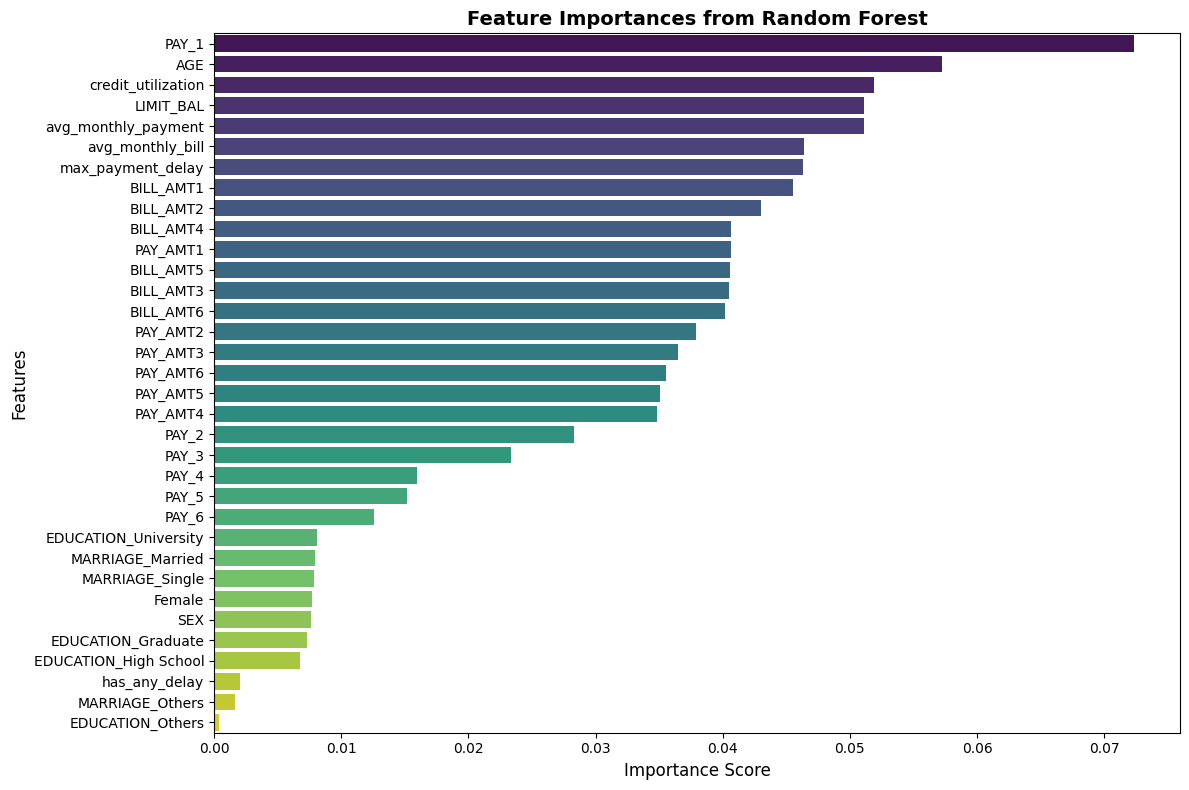

In [6]:
# Train RandomForest for feature importance analysis
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(x_train, y_train)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances, x='importance', y='feature', palette='viridis')
plt.title('Feature Importances from Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '' 'feature_importances.png'), dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Define selected features (top features with importance > threshold or top N features)
# Using top 20 features as baseline
n_features = 20
selected_features = feature_importances.head(n_features)['feature'].tolist()

dummy_groups = [
    ['MARRIAGE_Married', 'MARRIAGE_Others', 'MARRIAGE_Single'],
    ['EDUCATION_Graduate', 'EDUCATION_High School', 'EDUCATION_Others', 'EDUCATION_University']
]

selected_features_set = set(selected_features)
for group in dummy_groups:
    if any(feature in selected_features_set for feature in group):
        selected_features_set.update(group)

selected_features = [feature for feature in x_train.columns if feature in selected_features_set]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

# Apply feature selection to all datasets
x_train_selected = x_train[selected_features]
x_train_scaled_selected = x_train_scaled[selected_features]

x_val_selected = x_val[selected_features]
x_val_scaled_selected = x_val_scaled[selected_features]

x_test_selected = x_test[selected_features]
x_test_scaled_selected = x_test_scaled[selected_features]

print(f"\nOriginal training set shape: {x_train.shape}")
print(f"Selected training set shape: {x_train_selected.shape}")
print(f"Original validation set shape: {x_val.shape}")
print(f"Selected validation set shape: {x_val_selected.shape}")
print(f"Original test set shape: {x_test.shape}")
print(f"Selected test set shape: {x_test_selected.shape}")

Selected 20 features:
['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'credit_utilization', 'avg_monthly_bill', 'avg_monthly_payment', 'max_payment_delay']

Original training set shape: (19240, 34)
Selected training set shape: (19240, 20)
Original validation set shape: (4440, 34)
Selected validation set shape: (4440, 20)
Original test set shape: (5921, 34)
Selected test set shape: (5921, 20)


## Model Training and Hyperparameter Tuning

### Logistic Regression

In [8]:
# Get best Logistic Regression model from Optuna study
# Define Optuna objective function
def tune_lr_classifier(X_train, y_train, X_val, y_val, n_trials, metric):
    
    def optuna_objective(trial):
        """
        Objective function for Optuna optimization.
        Optimizes the specified metric.
        """
        # Hyperparameters to tune
        solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])

        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
        if solver == 'lbfgs':
            l1_ratio = 0
         
        params = {
            'C': trial.suggest_float('C', 1e-4, 1e2, log=True),  # Inverse regularization strength
            'max_iter': trial.suggest_int('max_iter', 500, 2000, step=100),  # Max iterations
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),  # Handle imbalance
        }
        
        # Create model
        model = LogisticRegression(
            C=params['C'],
            solver=solver,
            l1_ratio=l1_ratio,
            max_iter=params['max_iter'],
            class_weight=params['class_weight'],
            random_state=RANDOM_STATE
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # Compute all metrics
        metrics = {
            'auc_roc':  roc_auc_score(y_val, y_pred_proba),
            'accuracy': accuracy_score(y_val, y_pred),
            'f1':       f1_score(y_val, y_pred),
            'recall':   recall_score(y_val, y_pred),
            'precision':precision_score(y_val, y_pred)
        }
        
        # Log all metrics but return only the specified one for optimization
        for metric_name, metric_value in metrics.items():
            trial.set_user_attr(metric_name, metric_value)
        
        return metrics[metric]

    # Create Optuna study
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )

    # Optimize
    print("\nRunning Optuna optimization (this may take a few minutes)...")
    study.optimize(optuna_objective, n_trials=n_trials, n_jobs=-1, show_progress_bar=True)

    return study, study.best_params, study.best_value

In [9]:
lr_study, lr_best_params, lr_best_score = tune_lr_classifier(
    x_train_scaled_selected, y_train_scaled, x_val_scaled_selected, y_val_scaled, n_trials=35, metric='auc_roc'
)

# Visualize optimization history
fig = plot_optimization_history(lr_study).show()
print(f"\n✅ Optimization Complete!")
print(f"Best AUC-ROC (CV): {lr_best_score:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in lr_best_params.items():
    print(f"  • {param}: {value}")

# Save Optuna results
optuna_results_lr = {
    'lr_best_params': lr_best_params,
    'lr_best_score': lr_best_score,
    'n_trials': len(lr_study.trials),
    'trials_df': lr_study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs'))
}

optuna_results_lr['trials_df'].to_csv(os.path.join(MODELS_DIR, 'lr_optuna_trials.csv'), index=False)
optuna_results_lr['trials_df'].sort_values('value', ascending=False).head(10)

[I 2026-05-05 20:53:59,790] A new study created in memory with name: no-name-69fd7a54-4d1a-4b3c-b11c-93acc39e44c2



Running Optuna optimization (this may take a few minutes)...


Best trial: 4. Best value: 0.733913:   9%|▊         | 3/35 [00:00<00:05,  6.00it/s]

[I 2026-05-05 20:54:00,226] Trial 7 finished with value: 0.7328464150681737 and parameters: {'solver': 'lbfgs', 'l1_ratio': 0.2628625093418936, 'C': 21.883528664584155, 'max_iter': 600, 'class_weight': None}. Best is trial 7 with value: 0.7328464150681737.
[I 2026-05-05 20:54:00,317] Trial 2 finished with value: 0.733660058532007 and parameters: {'solver': 'lbfgs', 'l1_ratio': 0.7076908384568351, 'C': 0.10656049890170363, 'max_iter': 1400, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.733660058532007.
[I 2026-05-05 20:54:00,369] Trial 4 finished with value: 0.7339128409673727 and parameters: {'solver': 'lbfgs', 'l1_ratio': 0.20586728255943332, 'C': 0.028833286963614233, 'max_iter': 700, 'class_weight': 'balanced'}. Best is trial 4 with value: 0.7339128409673727.


Best trial: 4. Best value: 0.733913:  11%|█▏        | 4/35 [00:00<00:05,  5.63it/s]

...

[I 2026-05-05 20:55:18,429] Trial 33 finished with value: 0.7374381904522552 and parameters: {'solver': 'saga', 'l1_ratio': 0.4327979170729105, 'C': 0.0004311443688729214, 'max_iter': 1800, 'class_weight': 'balanced'}. Best is trial 23 with value: 0.7390237858324222.


Best trial: 23. Best value: 0.739024: 100%|██████████| 35/35 [01:19<00:00,  2.28s/it]


[I 2026-05-05 20:55:19,479] Trial 34 finished with value: 0.7374355573018868 and parameters: {'solver': 'saga', 'l1_ratio': 0.4355740835462135, 'C': 0.000432775943164207, 'max_iter': 1800, 'class_weight': 'balanced'}. Best is trial 23 with value: 0.7390237858324222.



✅ Optimization Complete!
Best AUC-ROC (CV): 0.7390

Best Hyperparameters:
  • solver: saga
  • l1_ratio: 0.4790125143972436
  • C: 0.0018351592893951743
  • max_iter: 1600
  • class_weight: balanced


,number,value,params_C,params_class_weight,params_l1_ratio,params_max_iter,params_solver,user_attrs_accuracy,user_attrs_auc_roc,user_attrs_f1,user_attrs_precision,user_attrs_recall
23,23,0.739024,0.001835,balanced,0.479013,1600,saga,0.730856,0.739024,0.517562,0.431359,0.646821
25,25,0.738971,0.002468,balanced,0.471332,1700,saga,0.731532,0.738971,0.519742,0.432596,0.650858
21,21,0.738953,0.002620,balanced,0.496013,1700,saga,0.730856,0.738953,0.519115,0.431727,0.650858
18,18,0.738852,0.003336,balanced,0.561056,1400,saga,0.726577,0.738852,0.516720,0.426693,0.654894
27,27,0.738808,0.001609,balanced,0.454676,1700,saga,0.730856,0.738808,0.517562,0.431359,0.646821
17,17,0.738732,0.003673,balanced,0.574634,1400,saga,0.723649,0.738732,0.515211,0.423377,0.657921
26,26,0.738698,0.001720,balanced,0.517181,1700,saga,0.730856,0.738698,0.517562,0.431359,0.646821
22,22,0.738678,0.001640,balanced,0.494570,1600,saga,0.730856,0.738678,0.517562,0.431359,0.646821
19,19,0.738653,0.003662,NaN,0.621720,1500,saga,0.787613,0.738653,0.163265,0.676471,0.092836
24,24,0.738350,0.001455,balanced,0.474435,1700,saga,0.731081,0.738350,0.518160,0.431742,0.647830


In [10]:
joblib.dump(optuna_results_lr, os.path.join(MODELS_DIR, 'lr_optuna_results.pkl'))

['c:\\Users\\Memit\\OneDrive - INSTITUTO TECNOLOGICO AUTONOMO DE MEXICO\\Documentos\\AplicacionesTrabajo\\Bluetab\\default_credit_prediction\\outputs\\models\\binary_classification\\lr_optuna_results.pkl']

### XGBoost

In [11]:
# Get best XGBoost model from Optuna study
# Define Optuna objective function
def tune_xgb_classifier(X_train, y_train, X_val, y_val, n_trials, metric):

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    def optuna_objective(trial):
        """
        Objective function for Optuna optimization.
        Optimizes the specific metric.
        """

        handle_imbalance = trial.suggest_categorical('handle_imbalance', [True, False])

        params = {
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': scale_pos_weight if handle_imbalance else 1.0,
            'use_label_encoder': False,
            'eval_metric': 'logloss'
        }
        model = xgb.XGBClassifier(**params)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # Compute all metrics
        metrics = {
            'auc_roc':  roc_auc_score(y_val, y_pred_proba),
            'accuracy': accuracy_score(y_val, y_pred),
            'f1':       f1_score(y_val, y_pred),
            'recall':   recall_score(y_val, y_pred),
            'precision':precision_score(y_val, y_pred)
        }
        
        # Log all metrics but return only the specified one for optimization
        for metric_name, metric_value in metrics.items():
            trial.set_user_attr(metric_name, metric_value)
        
        return metrics[metric]

    # Create Optuna study
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )

    # Optimize
    print("\nRunning Optuna optimization (this may take a few minutes)...")
    study.optimize(optuna_objective, n_trials=n_trials, n_jobs=-1, show_progress_bar=True)

    return study, study.best_params, study.best_value

In [12]:
xgb_study, xgb_best_params, xgb_best_score = tune_xgb_classifier(
    x_train_selected, y_train, x_val_selected, y_val, n_trials=35, metric='auc_roc'
)

print(f"\n✅ Optimization Complete!")
print(f"Best AUC-ROC (CV): {xgb_best_score:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in xgb_best_params.items():
    print(f"  • {param}: {value}")

# Visualize optimization history
fig = plot_optimization_history(xgb_study).show()

# Save Optuna results
optuna_results_xgb = {
    'xgb_best_params': xgb_best_params,
    'xgb_best_score': xgb_best_score,
    'n_trials': len(xgb_study.trials),
    'trials_df': xgb_study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs'))
}

optuna_results_xgb['trials_df'].to_csv(os.path.join(MODELS_DIR, 'xgb_optuna_trials.csv'), index=False)
optuna_results_xgb['trials_df'].sort_values('value', ascending=False).head(10)

[I 2026-05-05 20:55:20,588] A new study created in memory with name: no-name-779383db-ccdf-4e18-a147-515ba2254327



Running Optuna optimization (this may take a few minutes)...


Best trial: 2. Best value: 0.782437:   3%|▎         | 1/35 [00:07<04:24,  7.78s/it]

[I 2026-05-05 20:55:28,364] Trial 2 finished with value: 0.782437267386765 and parameters: {'handle_imbalance': True, 'max_depth': 3, 'learning_rate': 0.03299393133656064, 'n_estimators': 241, 'subsample': 0.6037573905306495, 'colsample_bytree': 0.643470308147909}. Best is trial 2 with value: 0.782437267386765.


Best trial: 2. Best value: 0.782437:   6%|▌         | 2/35 [00:11<02:56,  5.36s/it]

...

Best trial: 21. Best value: 0.783309:  94%|█████████▍| 33/35 [00:48<00:01,  1.15it/s]

[I 2026-05-05 20:56:09,412] Trial 34 finished with value: 0.7829485374166278 and parameters: {'handle_imbalance': True, 'max_depth': 3, 'learning_rate': 0.00953140718975636, 'n_estimators': 283, 'subsample': 0.703168394961094, 'colsample_bytree': 0.7555748728089781}. Best is trial 21 with value: 0.783309132730966.
[I 2026-05-05 20:56:09,427] Trial 33 finished with value: 0.7828386765318133 and parameters: {'handle_imbalance': True, 'max_depth': 3, 'learning_rate': 0.009449970558451131, 'n_estimators': 287, 'subsample': 0.6870984979958853, 'colsample_bytree': 0.7712647139623867}. Best is trial 21 with value: 0.783309132730966.


Best trial: 21. Best value: 0.783309: 100%|██████████| 35/35 [00:51<00:00,  1.47s/it]

[I 2026-05-05 20:56:11,918] Trial 27 finished with value: 0.7798368851118459 and parameters: {'handle_imbalance': False, 'max_depth': 8, 'learning_rate': 0.0010384568463886437, 'n_estimators': 414, 'subsample': 0.6648471887846856, 'colsample_bytree': 0.7580407779813597}. Best is trial 21 with value: 0.783309132730966.

✅ Optimization Complete!
Best AUC-ROC (CV): 0.7833

Best Hyperparameters:
  • handle_imbalance: True
  • max_depth: 4
  • learning_rate: 0.016940831927684398
  • n_estimators: 239
  • subsample: 0.610373124440811
  • colsample_bytree: 0.6669245353439072


,number,value,params_colsample_bytree,params_handle_imbalance,params_learning_rate,params_max_depth,params_n_estimators,params_subsample,user_attrs_accuracy,user_attrs_auc_roc,user_attrs_f1,user_attrs_precision,user_attrs_recall
21,21,0.783309,0.666925,True,0.016941,4,239,0.610373,0.752928,0.783309,0.533787,0.461087,0.633703
23,23,0.783203,0.676108,True,0.026372,3,254,0.606897,0.749324,0.783203,0.532156,0.456052,0.638749
28,28,0.783189,0.754700,True,0.025831,3,267,0.684911,0.750676,0.783189,0.535069,0.458273,0.642785
34,34,0.782949,0.755575,True,0.009531,3,283,0.703168,0.748423,0.782949,0.532049,0.454871,0.640767
32,32,0.782891,0.763819,True,0.010098,3,288,0.693840,0.748649,0.782891,0.532663,0.455261,0.641776
24,24,0.782845,0.665138,True,0.024549,3,265,0.805460,0.748423,0.782845,0.532440,0.454936,0.641776
33,33,0.782839,0.771265,True,0.009450,3,287,0.687098,0.748874,0.782839,0.532886,0.455587,0.641776
31,31,0.782826,0.757082,True,0.009941,3,274,0.682564,0.749775,0.782826,0.532997,0.456772,0.639758
14,14,0.782748,0.657278,False,0.003816,4,407,0.659170,0.817793,0.782748,0.428269,0.714623,0.305752
29,29,0.782717,0.657156,True,0.025155,3,252,0.671677,0.749550,0.782717,0.533557,0.456569,0.641776


In [13]:
joblib.dump(optuna_results_xgb, os.path.join(MODELS_DIR, 'xgb_optuna_results.pkl'))

['c:\\Users\\Memit\\OneDrive - INSTITUTO TECNOLOGICO AUTONOMO DE MEXICO\\Documentos\\AplicacionesTrabajo\\Bluetab\\default_credit_prediction\\outputs\\models\\binary_classification\\xgb_optuna_results.pkl']

## Predict & Evaluation

FINAL MODEL TRAINING & EVALUATION | Logistic Regression

Training final model with best hyperparameters...

### Validation Set Performance
--------------------------------------------------------------------------------
AUC-ROC        : 0.7390
Accuracy       : 0.7309
Precision      : 0.4314
Recall         : 0.6468
F1-Score       : 0.5176

Confusion Matrix (Validation):
[[2604  845]
 [ 350  641]]

Classification Report (Validation):
              precision    recall  f1-score   support

  No Default       0.88      0.76      0.81      3449
     Default       0.43      0.65      0.52       991

    accuracy                           0.73      4440
   macro avg       0.66      0.70      0.67      4440
weighted avg       0.78      0.73      0.75      4440


### Test Set Performance
--------------------------------------------------------------------------------
AUC-ROC        : 0.7320
Accuracy       : 0.7355
Precision      : 0.4365
Recall         : 0.6374
F1-Score       : 0.5182

Confusion

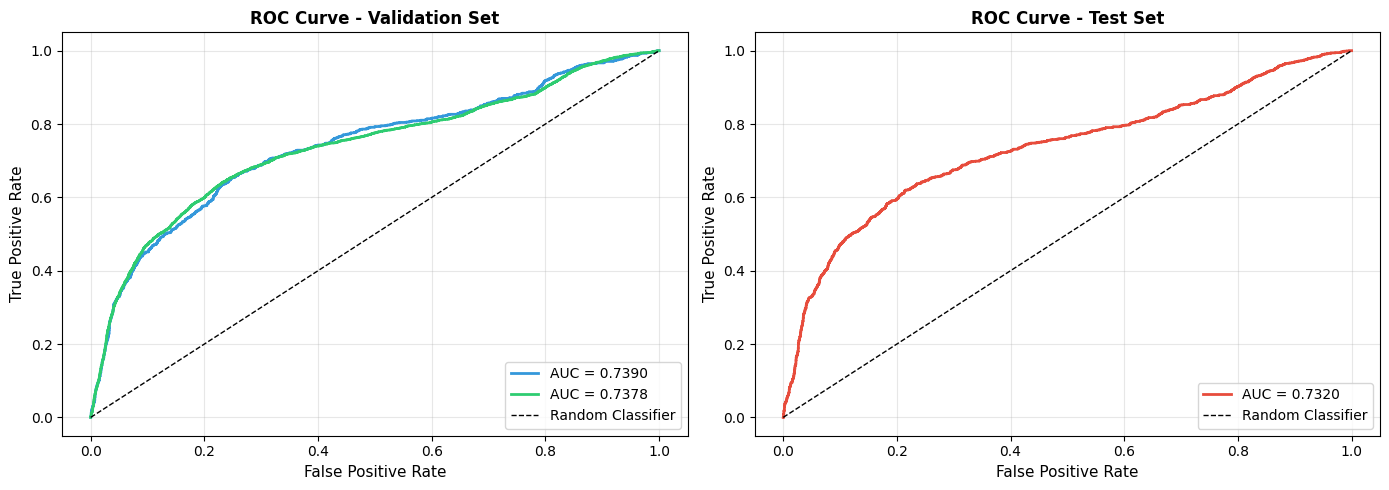

In [14]:
print("FINAL MODEL TRAINING & EVALUATION | Logistic Regression")
print("="*80)

# Use best model
print("\nTraining final model with best hyperparameters...")
best_lr_model = LogisticRegression(
    C=lr_best_params['C'],
    solver=lr_best_params['solver'],
    l1_ratio = lr_best_params['l1_ratio'],
    max_iter=lr_best_params['max_iter'],
    class_weight=lr_best_params['class_weight'],
    random_state=RANDOM_STATE
)

# Train on full training set
best_lr_model.fit(x_train_scaled_selected, y_train_scaled)

# ========== VALIDATION SET EVALUATION ==========
print("\n### Validation Set Performance")
print("-" * 80)

y_tr_pred = best_lr_model.predict(x_train_scaled_selected)
y_tr_pred_proba = best_lr_model.predict_proba(x_train_scaled_selected)[:, 1]

y_val_pred = best_lr_model.predict(x_val_scaled_selected)
y_val_pred_proba = best_lr_model.predict_proba(x_val_scaled_selected)[:, 1]

val_metrics = {
    'AUC-ROC': roc_auc_score(y_val_scaled, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val_scaled, y_val_pred),
    'Precision': precision_score(y_val_scaled, y_val_pred),
    'Recall': recall_score(y_val_scaled, y_val_pred),
    'F1-Score': f1_score(y_val_scaled, y_val_pred)
}

for metric, value in val_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val_scaled, y_val_pred))

print("\nClassification Report (Validation):")
print(classification_report(y_val_scaled, y_val_pred, target_names=['No Default', 'Default']))

# ========== TEST SET EVALUATION ==========
print("\n### Test Set Performance")
print("-" * 80)

y_test_pred = best_lr_model.predict(x_test_scaled_selected)
y_test_pred_proba = best_lr_model.predict_proba(x_test_scaled_selected)[:, 1]

test_metrics = {
    'AUC-ROC': roc_auc_score(y_test_scaled, y_test_pred_proba),
    'Accuracy': accuracy_score(y_test_scaled, y_test_pred),
    'Precision': precision_score(y_test_scaled, y_test_pred),
    'Recall': recall_score(y_test_scaled, y_test_pred),
    'F1-Score': f1_score(y_test_scaled, y_test_pred)
}

for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_scaled, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test_scaled, y_test_pred, target_names=['No Default', 'Default']))

# ========== ROC CURVE VISUALIZATION ==========
print("\n### ROC Curve Comparison")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation ROC
fpr_val, tpr_val, _ = roc_curve(y_val_scaled, y_val_pred_proba)
auc_val = roc_auc_score(y_val_scaled, y_val_pred_proba)
axes[0].plot(fpr_val, tpr_val, lw=2, label=f'AUC = {auc_val:.4f}', color='#3498db')
fpr_val, tpr_val, _ = roc_curve(y_train_scaled, y_tr_pred_proba)
auc_val = roc_auc_score(y_train_scaled, y_tr_pred_proba)
axes[0].plot(fpr_val, tpr_val, lw=2, label=f'AUC = {auc_val:.4f}', color='#2ecc71')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve - Validation Set', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test_scaled, y_test_pred_proba)
auc_test = roc_auc_score(y_test_scaled, y_test_pred_proba)
axes[1].plot(fpr_test, tpr_test, lw=2, label=f'AUC = {auc_test:.4f}', color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()


### Feature Importance (Logistic Coefficients)
--------------------------------------------------------------------------------

Top 15 Most Important Features:
          feature  coefficient  abs_coefficient
max_payment_delay     0.320302         0.320302
            PAY_1     0.172128         0.172128
         PAY_AMT1    -0.039251         0.039251
         PAY_AMT2    -0.033724         0.033724
        LIMIT_BAL    -0.030940         0.030940
         PAY_AMT5    -0.017316         0.017316
         PAY_AMT4    -0.017315         0.017315
        BILL_AMT1    -0.013626         0.013626
            PAY_2     0.011936         0.011936
         PAY_AMT3    -0.009155         0.009155
              AGE     0.008619         0.008619
         PAY_AMT6    -0.005407         0.005407
        BILL_AMT5     0.000000         0.000000
        BILL_AMT6     0.000000         0.000000
        BILL_AMT3     0.000000         0.000000


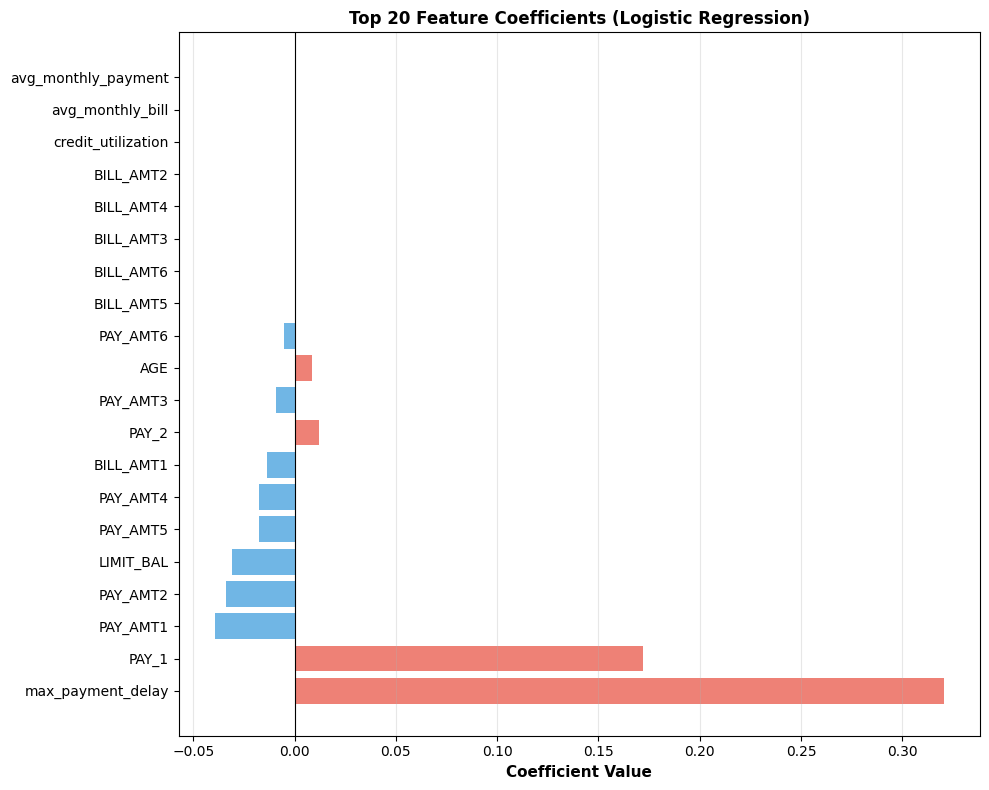


### Saving Model and Artifacts
--------------------------------------------------------------------------------


In [15]:
print("\n### Feature Importance (Logistic Coefficients)")
print("-" * 80)

coefficients = pd.DataFrame({
    'feature': selected_features,
    'coefficient': best_lr_model.coef_[0],
    'abs_coefficient': np.abs(best_lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 15 Most Important Features:")
print(coefficients.head(15).to_string(index=False))

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 8))
top_coefs = coefficients.head(20)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_coefs['coefficient']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'].values, color=colors, alpha=0.7)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'].values, fontsize=10)
ax.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Feature Coefficients (Logistic Regression)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'feature_coefficients.png'), dpi=300, bbox_inches='tight')
plt.show()

# ========== SAVE MODEL & ARTIFACTS ==========
print("\n### Saving Model and Artifacts")
print("-" * 80)

# Save model
joblib.dump(best_lr_model, os.path.join(MODELS_DIR, 'logistic_model.pkl'))

# Save selected features list
with open(os.path.join(MODELS_DIR, 'selected_features.pkl'), 'wb') as f:
    pickle.dump(selected_features, f)

# Save results summary
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'model_type': 'LogisticRegression',
    'hyperparameters': lr_best_params,
    'selected_features': selected_features,
    'n_features_selected': len(selected_features),
    'n_features_original': x_train_scaled.shape[1],
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'feature_importance': coefficients.to_dict()
}

with open(os.path.join(MODELS_DIR, 'LR_results_summary.pkl'), 'wb') as f:
    pickle.dump(results_summary, f)

FINAL MODEL TRAINING & EVALUATION | XG Boost

Training final model with best hyperparameters...

### Validation Set Performance
--------------------------------------------------------------------------------
AUC-ROC        : 0.7832
Accuracy       : 0.8194
Precision      : 0.6879
Recall         : 0.3491
F1-Score       : 0.4632

Confusion Matrix (Validation):
[[3292  157]
 [ 645  346]]

Classification Report (Validation):
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      3449
     Default       0.69      0.35      0.46       991

    accuracy                           0.82      4440
   macro avg       0.76      0.65      0.68      4440
weighted avg       0.80      0.82      0.80      4440


### Test Set Performance
--------------------------------------------------------------------------------
AUC-ROC        : 0.7755
Accuracy       : 0.8237
Precision      : 0.6926
Recall         : 0.3770
F1-Score       : 0.4882

Confusion Matrix (Te

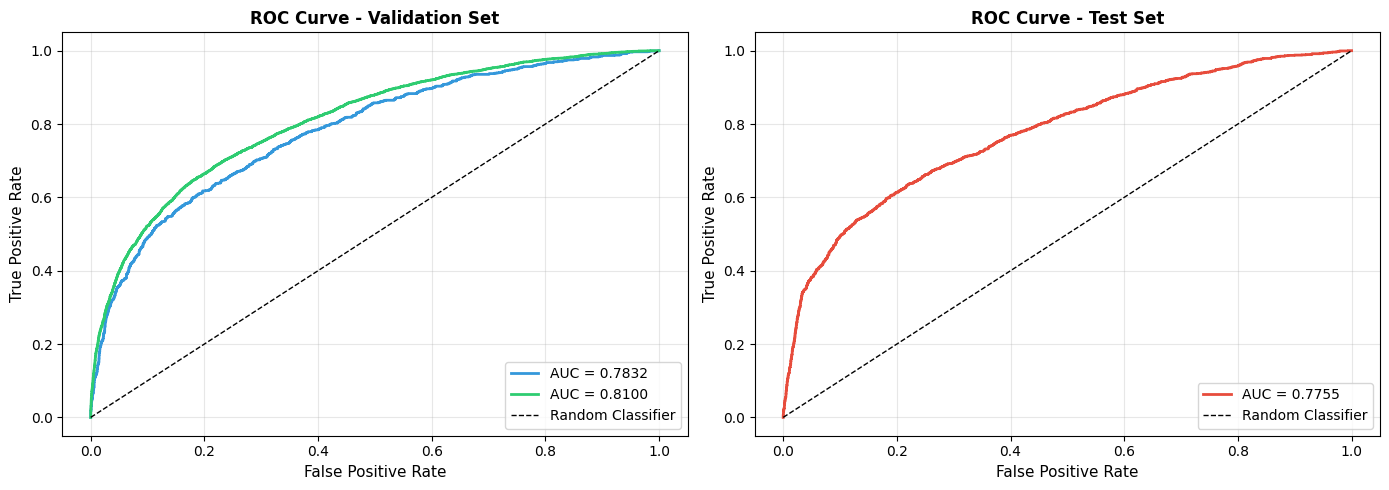

In [16]:
print("FINAL MODEL TRAINING & EVALUATION | XG Boost")
print("="*80)

# Use best model
print("\nTraining final model with best hyperparameters...")
best_xgb_model = xgb.XGBClassifier(
    max_depth=xgb_best_params['max_depth'],
    learning_rate=xgb_best_params['learning_rate'],
    n_estimators=xgb_best_params['n_estimators'],
    subsample=xgb_best_params['subsample'],
    colsample_bytree=xgb_best_params['colsample_bytree'],
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train on full training set
best_xgb_model.fit(x_train_scaled_selected, y_train_scaled)

# ========== VALIDATION SET EVALUATION ==========
print("\n### Validation Set Performance")
print("-" * 80)

y_tr_pred = best_xgb_model.predict(x_train_scaled_selected)
y_tr_pred_proba = best_xgb_model.predict_proba(x_train_scaled_selected)[:, 1]

y_val_pred = best_xgb_model.predict(x_val_scaled_selected)
y_val_pred_proba = best_xgb_model.predict_proba(x_val_scaled_selected)[:, 1]

val_metrics = {
    'AUC-ROC': roc_auc_score(y_val_scaled, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val_scaled, y_val_pred),
    'Precision': precision_score(y_val_scaled, y_val_pred),
    'Recall': recall_score(y_val_scaled, y_val_pred),
    'F1-Score': f1_score(y_val_scaled, y_val_pred)
}

for metric, value in val_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val_scaled, y_val_pred))

print("\nClassification Report (Validation):")
print(classification_report(y_val_scaled, y_val_pred, target_names=['No Default', 'Default']))

# ========== TEST SET EVALUATION ==========
print("\n### Test Set Performance")
print("-" * 80)

y_test_pred = best_xgb_model.predict(x_test_scaled_selected)
y_test_pred_proba = best_xgb_model.predict_proba(x_test_scaled_selected)[:, 1]

test_metrics = {
    'AUC-ROC': roc_auc_score(y_test_scaled, y_test_pred_proba),
    'Accuracy': accuracy_score(y_test_scaled, y_test_pred),
    'Precision': precision_score(y_test_scaled, y_test_pred),
    'Recall': recall_score(y_test_scaled, y_test_pred),
    'F1-Score': f1_score(y_test_scaled, y_test_pred)
}

for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_scaled, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test_scaled, y_test_pred, target_names=['No Default', 'Default']))

# ========== ROC CURVE VISUALIZATION ==========
print("\n### ROC Curve Comparison")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation ROC
fpr_val, tpr_val, _ = roc_curve(y_val_scaled, y_val_pred_proba)
auc_val = roc_auc_score(y_val_scaled, y_val_pred_proba)
axes[0].plot(fpr_val, tpr_val, lw=2, label=f'AUC = {auc_val:.4f}', color='#3498db')
fpr_val, tpr_val, _ = roc_curve(y_train_scaled, y_tr_pred_proba)
auc_val = roc_auc_score(y_train_scaled, y_tr_pred_proba)
axes[0].plot(fpr_val, tpr_val, lw=2, label=f'AUC = {auc_val:.4f}', color='#2ecc71')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve - Validation Set', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test_scaled, y_test_pred_proba)
auc_test = roc_auc_score(y_test_scaled, y_test_pred_proba)
axes[1].plot(fpr_test, tpr_test, lw=2, label=f'AUC = {auc_test:.4f}', color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()


### Feature Importance (Logistic Coefficients)
--------------------------------------------------------------------------------
XGBoost Test Set Metrics
----------------------------------------
AUC-ROC   : 0.7755
Accuracy  : 0.8237
Precision : 0.6926
Recall    : 0.3770
F1-Score  : 0.4882


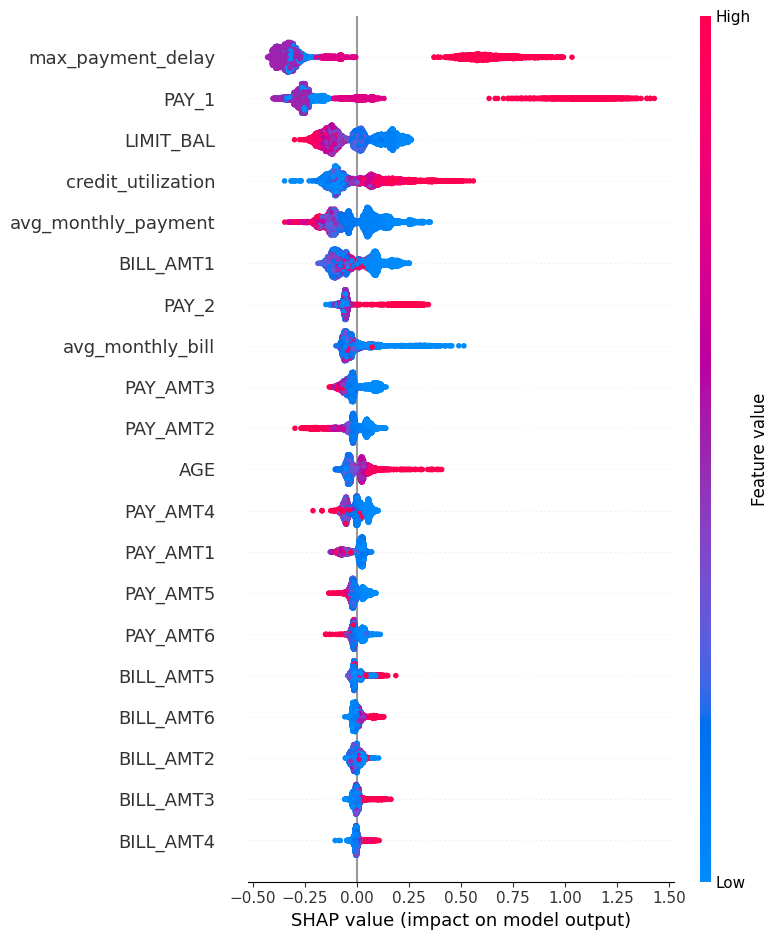

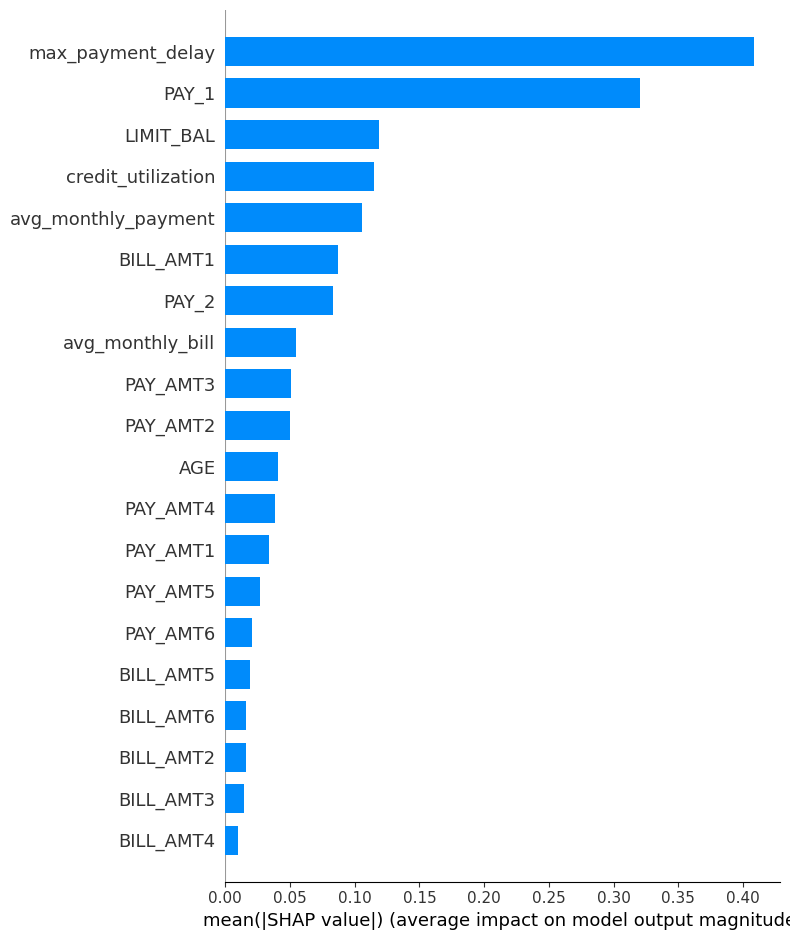


### Saving Model and Artifacts
--------------------------------------------------------------------------------


In [17]:
print("\n### Feature Importance (Logistic Coefficients)")
print("-" * 80)

explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(x_test_scaled_selected)

y_test_pred_xgb = best_xgb_model.predict(x_test_scaled_selected)
y_test_pred_proba_xgb = best_xgb_model.predict_proba(x_test_scaled_selected)[:, 1]

xgb_test_metrics = {
    'AUC-ROC': roc_auc_score(y_test_scaled, y_test_pred_proba_xgb),
    'Accuracy': accuracy_score(y_test_scaled, y_test_pred_xgb),
    'Precision': precision_score(y_test_scaled, y_test_pred_xgb),
    'Recall': recall_score(y_test_scaled, y_test_pred_xgb),
    'F1-Score': f1_score(y_test_scaled, y_test_pred_xgb)
}

print("XGBoost Test Set Metrics")
print("-" * 40)
for metric, value in xgb_test_metrics.items():
    print(f"{metric:10s}: {value:.4f}")


shap.summary_plot(shap_values, x_test_scaled_selected, feature_names=x_test_scaled_selected.columns)
shap.summary_plot(shap_values, x_test_scaled_selected, feature_names=x_test_scaled_selected.columns, plot_type='bar')

# ========== SAVE MODEL & ARTIFACTS ==========
print("\n### Saving Model and Artifacts")
print("-" * 80)

# Save model
joblib.dump(best_xgb_model, os.path.join(MODELS_DIR, 'xgb_model.pkl'))

# Save results summary
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'model_type': 'XGBoostClassifier',
    'hyperparameters': xgb_best_params,
    'selected_features': selected_features,
    'n_features_selected': len(selected_features),
    'n_features_original': x_train_scaled.shape[1],
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'feature_importance': coefficients.to_dict()
}

with open(os.path.join(MODELS_DIR, 'XGB_results_summary.pkl'), 'wb') as f:
    pickle.dump(results_summary, f)

## Model Comparison Summary

In [18]:
# Function to compute all required metrics
def compute_metrics(y_true, y_pred, y_pred_proba):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    # KS statistic: max difference between CDFs of positive and negative classes
    pos_proba = y_pred_proba[y_true == 1]
    neg_proba = y_pred_proba[y_true == 0]
    ks_stat, _ = ks_2samp(pos_proba, neg_proba)
    return acc, rec, f1, auc, gini, ks_stat

# Compute metrics for Logistic Regression
# Train
y_train_pred_lr = best_lr_model.predict(x_train_scaled_selected)
y_train_pred_proba_lr = best_lr_model.predict_proba(x_train_scaled_selected)[:, 1]
train_acc_lr, train_rec_lr, train_f1_lr, train_auc_lr, train_gini_lr, train_ks_lr = compute_metrics(y_train_scaled, y_train_pred_lr, y_train_pred_proba_lr)

# Validation
y_val_pred_lr = best_lr_model.predict(x_val_scaled_selected)
y_val_pred_proba_lr = best_lr_model.predict_proba(x_val_scaled_selected)[:, 1]
val_acc_lr, val_rec_lr, val_f1_lr, val_auc_lr, val_gini_lr, val_ks_lr = compute_metrics(y_val_scaled, y_val_pred_lr, y_val_pred_proba_lr)

# Test
y_test_pred_lr = best_lr_model.predict(x_test_scaled_selected)
y_test_pred_proba_lr = best_lr_model.predict_proba(x_test_scaled_selected)[:, 1]
test_acc_lr, test_rec_lr, test_f1_lr, test_auc_lr, test_gini_lr, test_ks_lr = compute_metrics(y_test_scaled, y_test_pred_lr, y_test_pred_proba_lr)

# Compute metrics for XGBoost (using existing predictions) - possible fix for future
# Train
train_acc_xgb, train_rec_xgb, train_f1_xgb, train_auc_xgb, train_gini_xgb, train_ks_xgb = compute_metrics(y_train, y_tr_pred, y_tr_pred_proba)

# Validation
val_acc_xgb, val_rec_xgb, val_f1_xgb, val_auc_xgb, val_gini_xgb, val_ks_xgb = compute_metrics(y_val, y_val_pred, y_val_pred_proba)

# Test
test_acc_xgb, test_rec_xgb, test_f1_xgb, test_auc_xgb, test_gini_xgb, test_ks_xgb = compute_metrics(y_test, y_test_pred, y_test_pred_proba)

# Create DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression'] * 3 + ['XGBoost'] * 3,
    'Dataset': ['Train', 'Validation', 'Test'] * 2,
    'Accuracy': [train_acc_lr, val_acc_lr, test_acc_lr, train_acc_xgb, val_acc_xgb, test_acc_xgb],
    'Recall': [train_rec_lr, val_rec_lr, test_rec_lr, train_rec_xgb, val_rec_xgb, test_rec_xgb],
    'F1-Score': [train_f1_lr, val_f1_lr, test_f1_lr, train_f1_xgb, val_f1_xgb, test_f1_xgb],
    'AUC-ROC': [train_auc_lr, val_auc_lr, test_auc_lr, train_auc_xgb, val_auc_xgb, test_auc_xgb],
    'Gini': [train_gini_lr, val_gini_lr, test_gini_lr, train_gini_xgb, val_gini_xgb, test_gini_xgb],
    'KS': [train_ks_lr, val_ks_lr, test_ks_lr, train_ks_xgb, val_ks_xgb, test_ks_xgb]

})
# Set double level index for Model and Dataset
comparison_df.set_index(['Model', 'Dataset'], inplace=True)
# Print the DataFrame
comparison_df

Accuracy    Recall  F1-Score   AUC-ROC  \
Model               Dataset                                              
Logistic Regression Train       0.737838  0.642208  0.522258  0.737811   
                    Validation  0.730856  0.646821  0.517562  0.739024   
                    Test        0.735518  0.637396  0.518154  0.731950   
XGBoost             Train       0.825624  0.369439  0.485981  0.809992   
                    Validation  0.819369  0.349142  0.463186  0.783204   
                    Test        0.823678  0.376987  0.488235  0.775541   

                                    Gini        KS  
Model               Dataset                         
Logistic Regression Train       0.475623  0.409658  
                    Validation  0.478048  0.405268  
                    Test        0.463900  0.404767  
XGBoost             Train       0.619984  0.466868  
                    Validation  0.566409  0.420689  
                    Test        0.551082  0.415882

In [19]:
# Best model by metric in test set
test_comparison = comparison_df.xs('Test', level='Dataset')

for metric in test_comparison.columns:
    best_model = test_comparison[metric].idxmax()
    best_value = test_comparison.loc[best_model, metric]
    print(f"Best {metric}: {best_model} with value {best_value:.4f}")

Best Accuracy: XGBoost with value 0.8237
Best Recall: Logistic Regression with value 0.6374
Best F1-Score: Logistic Regression with value 0.5182
Best AUC-ROC: XGBoost with value 0.7755
Best Gini: XGBoost with value 0.5511
Best KS: XGBoost with value 0.4159
